# Read and visualize a DICOM image
This example show how to read a DICOM file and how to visualize the metadata and to plot the medical image stored in that file.

A DICOM file contains:
* The image pixel data
* Metadata (patient info, modality, spacing, orientation, etc.)

In this notebook, we will:
* Load a DICOM file
* Explore its metadata
* Extract pixel data
* Visualize the image correctly


In [1]:
%matplotlib inline

`%matplotlib inline`
is a ‘magic functions’ which sets the backend of matplotlib to the 'inline' backend. It allows to display  the output of plotting commands inline within frontends like the Jupyter notebook, directly below the code cell that produced it. The resulting plots will then also be stored in the notebook document.

## Reading the dataset from Google Drive


Prior to this operation be sure to have added the [shared folder](https://drive.google.com/open?id=1YqK7ZkM-P2IrqfD7Pj-SCmjz-GWd_1-Y) to your Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!ls "/content/drive/My Drive/DATASETS"

FEATURES  IMAGES  README.rtf


In [9]:
DATASETS = "/content/drive/My Drive/DATASETS"

## Reading the dataset from a local folder

In [ ]:
# Set this to your local dataset folder
#DATASETS = "/Users/retico/Desktop/CMEPDA/DATASETS"

## Reading a DICOM file using the pydicom package

This example illustrates how to use the pydicom package to open a DICOM file, print some dataset information (metadata), and show images using matplotlib.

Find the documentation and the installation instructions at
https://pydicom.github.io/pydicom/stable/

You can create and work in an enviroment with python 3 and the numpy library, which is required to manipulate pixel data

In [5]:
%pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.9 MB/s eta 0:00:00


In [10]:
import os
import pydicom
import matplotlib.pyplot as plt

`pydicom.dcmread()` reads the file into a Python object

In [11]:
filename = os.path.join(DATASETS, "IMAGES", "DICOM_Examples", "Brain_MRI", "IM67_1slice.dcm")
dataset = pydicom.dcmread(filename)

The `dcmread` function returns a *FileDataset* object, which makes accessible the metadata contained in the DICOM header and the image as numpy array.

In [12]:
print(type(dataset)) # confirms the object is a `FileDataset`

<class 'pydicom.dataset.FileDataset'>


to show the dataset content you can use print(dataset) or just type dataset.
It prints a compact summary of top-level tags (file meta, header fields). Pixel data is not expanded by this print

In [13]:
dataset

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 228
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.2.4365715539284982230698868930013138318
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.3.100.9.4
(0002,0013) Implementation Version Name         SH: 'MATLAB IPT 9.4'
(0002,0016) Source Application Entity Title     AE: 'SMARDicomSCP'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OTHER']
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9590.100.1.2.4

A dataset with pixel data should always contain group 0x0028 Image Pixel module elements, which are needed to properly interpret the encoded pixel data byte stream:

In [14]:
dataset.group_dataset(0x0028)

(0028,0002) Samples per Pixel                   US: 1
(0028,0004) Photometric Interpretation          CS: 'MONOCHROME2'
(0028,0010) Rows                                US: 512
(0028,0011) Columns                             US: 512
(0028,0030) Pixel Spacing                       DS: [0.5, 0.5]
(0028,0100) Bits Allocated                      US: 16
(0028,0101) Bits Stored                         US: 16
(0028,0102) High Bit                            US: 15
(0028,0103) Pixel Representation                US: 1
(0028,0106) Smallest Image Pixel Value          SS: 0
(0028,0107) Largest Image Pixel Value           SS: 4305
(0028,1050) Window Center                       DS: '2152'
(0028,1051) Window Width                        DS: '4305'

To visualize  some values of interest we can write a block of `print(...)` statements: it extracts and formats metadata (PatientName, PatientID, Modality, StudyDate) and prints image size and PixelSpacing if `PixelData` exists.

In [15]:
print()
print("Filename.........:", filename)
print("Storage type.....:", dataset.SOPClassUID)
print()

pat_name = dataset.PatientName
display_name = pat_name.family_name + ", " + pat_name.given_name
display_name = ','.join([pat_name.family_name, pat_name.given_name])
print("Patient's name...:", display_name)
print("Patient id.......:", dataset.PatientID)
print("Modality.........:", dataset.Modality)
print("Study Date.......:", dataset.StudyDate)

if 'PixelData' in dataset:
    rows = int(dataset.Rows)
    cols = int(dataset.Columns)
    print("Image size.......: {rows:d} x {cols:d}, {size:d} bytes".format(
        rows=rows, cols=cols, size=len(dataset.PixelData)))
    if 'PixelSpacing' in dataset:
        print("Pixel spacing....:", dataset.PixelSpacing)



Filename.........: /content/drive/My Drive/DATASETS/IMAGES/DICOM_Examples/Brain_MRI/IM67_1slice.dcm
Storage type.....: 1.2.840.10008.5.1.4.1.1.4

Patient's name...: Maria Bianchi,
Patient id.......: 1234
Modality.........: MR
Study Date.......: 20170217
Image size.......: 512 x 512, 524288 bytes
Pixel spacing....: [0.5, 0.5]


Use `.get()` if not sure the item exists, and want a default value if missing. The `.get()` method avoids errors if a field is missing.

In [16]:
print("Slice location...:", dataset.get('SliceLocation', "(missing)"))

Slice location...: 32.98758698


Images are NumPy n-dimentional arrays

 pydicom offers the pixel_array() method for converting DICOM pixel data to a NumPy ndarray for numeric processing:

In [17]:
data_array = dataset.pixel_array

In [18]:
data_array.shape

(512, 512)

In [ ]:
print(type(data_array))

<class 'numpy.ndarray'>


## Image visualization

Basic image visualization can be done with `matplotlib` (imshow)

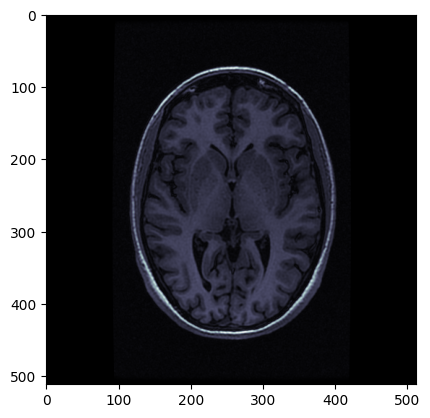

In [19]:
# plot the image using matplotlib
plt.imshow(data_array, cmap=plt.cm.bone)
plt.show()